In [1]:
import pandas as pd
import numpy as np

In [3]:
# ============================================================
# 1. LOAD FEATURE DATASET
# ============================================================

DATA_PATH = "../data/processed/paysim_features.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (6362620, 24)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'log_amount', 'hour', 'day', 'origin_balance_utilization', 'origin_balance_zero', 'destination_balance_zero', 'full_origin_balance_transfer', 'destination_previous_transactions', 'origin_previous_transactions', 'origin_balance_depleted', 'destination_balance_change', 'origin_balance_change', 'amount_to_destination_balance', 'zero_amount_transaction']


In [4]:
# ============================================================
# 2. DEFINE TARGET AND ML FEATURES
# ============================================================

target = "isFraud"

features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "log_amount",
    "hour",
    "day",
    "origin_balance_utilization",
    "origin_balance_zero",
    "destination_balance_zero",
    "full_origin_balance_transfer",
    "destination_previous_transactions",
    "origin_balance_depleted",
    "destination_balance_change",
    "origin_balance_change",
    "amount_to_destination_balance",
    "zero_amount_transaction"
]

print("Number of ML features:", len(features))
print("\nML Features:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

print("\nTarget:", target)

Number of ML features: 20

ML Features:
1. step
2. type
3. amount
4. oldbalanceOrg
5. newbalanceOrig
6. oldbalanceDest
7. newbalanceDest
8. log_amount
9. hour
10. day
11. origin_balance_utilization
12. origin_balance_zero
13. destination_balance_zero
14. full_origin_balance_transfer
15. destination_previous_transactions
16. origin_balance_depleted
17. destination_balance_change
18. origin_balance_change
19. amount_to_destination_balance
20. zero_amount_transaction

Target: isFraud


In [5]:
# ============================================================
# 3. INSPECT TEMPORAL RANGE
# ============================================================

print("Minimum step:", df["step"].min())
print("Maximum step:", df["step"].max())

print("\nTransactions per step:")
print(
    df["step"]
    .value_counts()
    .sort_index()
    .head(10)
)

print("\nLast 10 steps:")
print(
    df["step"]
    .value_counts()
    .sort_index()
    .tail(10)
)

Minimum step: 1
Maximum step: 743

Transactions per step:
step
1      2708
2      1014
3       552
4       565
5       665
6      1660
7      6837
8     21097
9     37628
10    35991
Name: count, dtype: int64

Last 10 steps:
step
734     8
735    12
736    14
737    10
738    10
739    10
740     6
741    22
742    14
743     8
Name: count, dtype: int64


In [6]:
# ============================================================
# 4. TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_mask = df["step"] <= 600
val_mask = (df["step"] > 600) & (df["step"] <= 670)
test_mask = df["step"] > 670

print("Training transactions:", train_mask.sum())
print("Validation transactions:", val_mask.sum())
print("Test transactions:", test_mask.sum())

print("\nTraining step range:", df.loc[train_mask, "step"].min(),
      "to", df.loc[train_mask, "step"].max())

print("Validation step range:", df.loc[val_mask, "step"].min(),
      "to", df.loc[val_mask, "step"].max())

print("Test step range:", df.loc[test_mask, "step"].min(),
      "to", df.loc[test_mask, "step"].max())

Training transactions: 6259047
Validation transactions: 36953
Test transactions: 66620

Training step range: 1 to 600
Validation step range: 601 to 670
Test step range: 671 to 743


In [7]:
# ============================================================
# 5. FRAUD DISTRIBUTION ACROSS TIME SPLITS
# ============================================================

split_stats = pd.DataFrame({
    "Train": df.loc[train_mask, "isFraud"].value_counts(),
    "Validation": df.loc[val_mask, "isFraud"].value_counts(),
    "Test": df.loc[test_mask, "isFraud"].value_counts()
}).fillna(0).astype(int)

split_stats.index = ["Legitimate", "Fraud"]

split_stats["Train %"] = (
    split_stats["Train"] /
    split_stats["Train"].sum() * 100
)

split_stats["Validation %"] = (
    split_stats["Validation"] /
    split_stats["Validation"].sum() * 100
)

split_stats["Test %"] = (
    split_stats["Test"] /
    split_stats["Test"].sum() * 100
)

split_stats.round(4)

,Train,Validation,Test,Train %,Validation %,Test %
Legitimate,6252434,36179,65794,99.8943,97.9054,98.7601
Fraud,6613,774,826,0.1057,2.0946,1.2399


In [9]:
# ============================================================
# 6. CREATE TRAIN / VALIDATION / TEST DATA
# ============================================================

train_df = df.loc[train_mask, features + [target]]
val_df = df.loc[val_mask, features + [target]]
test_df = df.loc[test_mask, features + [target]]

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (6259047, 21)
Validation shape: (36953, 21)
Test shape: (66620, 21)


In [10]:
# ============================================================
# 7. MISSING VALUES IN ML SPLITS
# ============================================================

missing_features = [
    "origin_balance_utilization",
    "amount_to_destination_balance"
]

for split_name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{split_name}")
    print("-" * 50)

    missing = split_df[missing_features].isna().sum()
    missing_percent = (
        missing / len(split_df) * 100
    )

    print(
        pd.DataFrame({
            "Missing Values": missing,
            "Missing %": missing_percent.round(4)
        })
    )


Train
--------------------------------------------------
                               Missing Values  Missing %
origin_balance_utilization            2075731    33.1637
amount_to_destination_balance         2657511    42.4587

Validation
--------------------------------------------------
                               Missing Values  Missing %
origin_balance_utilization               9755    26.3984
amount_to_destination_balance           16927    45.8068

Test
--------------------------------------------------
                               Missing Values  Missing %
origin_balance_utilization              16963    25.4623
amount_to_destination_balance           29950    44.9565


In [11]:
# ============================================================
# 8. BUILD PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [12]:

categorical_features = ["type"]

numeric_features_ml = [feature for feature in features if feature not in categorical_features]

numeric_features_ml.remove("step")
numeric_features_ml.remove("hour")
numeric_features_ml.remove("day")

numeric_features_ml.extend([
    "step",
    "hour",
    "day"
])

ratio_features = ["origin_balance_utilization","amount_to_destination_balance"]

numeric_imputer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=True)
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_imputer,
            numeric_features_ml
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Numeric features:", len(numeric_features_ml))
print("Categorical features:", categorical_features)
print("\nPreprocessor created successfully.")

Numeric features: 19
Categorical features: ['type']

Preprocessor created successfully.


In [15]:
# ============================================================
# 9. FIT AND TRANSFORM DATA
# ============================================================

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test using training-fitted preprocessor
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Validation processed shape:", X_val_processed.shape)
print("Test processed shape:", X_test_processed.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Training processed shape: (6259047, 24)
Validation processed shape: (36953, 24)
Test processed shape: (66620, 24)

Target shapes:
y_train: (6259047,)
y_val: (36953,)
y_test: (66620,)


In [16]:
# ============================================================
# 10. TRAIN ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest

In [20]:
# Use a representative training sample
sample_size = 250_000

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_train_processed.shape[0],
    size=sample_size,
    replace=False
)

X_train_sample = X_train_processed[sample_indices]

print("Isolation Forest training sample shape:", X_train_sample.shape)



Isolation Forest training sample shape: (250000, 24)


In [21]:
# Create Isolation Forest
isolation_forest = IsolationForest(
        n_estimators=200,
        max_samples='auto',
        contamination='auto',
        random_state=42,
        n_jobs=-1
)

isolation_forest.fit(X_train_sample)

print("\nIsolation Forest training completed successfully.")


Isolation Forest training completed successfully.


In [22]:
# ============================================================
# 11. GENERATE ANOMALY SCORES
# ============================================================

# Generate anomaly scores
# Higher score = more normal
# Lower score = more anomalous

val_scores = isolation_forest.decision_function(X_val_processed)
test_scores = isolation_forest.decision_function(X_test_processed)

print("Validation anomaly scores:")
print("Shape:", val_scores.shape)
print("Min:", val_scores.min())
print("Max:", val_scores.max())
print("Mean:", val_scores.mean())

print("\nTest anomaly scores:")
print("Shape:", test_scores.shape)
print("Min:", test_scores.min())
print("Max:", test_scores.max())
print("Mean:", test_scores.mean())

Validation anomaly scores:
Shape: (36953,)
Min: -0.22274511874234526
Max: 0.061913568129427776
Mean: 0.012493528313422304

Test anomaly scores:
Shape: (66620,)
Min: -0.22309113376500256
Max: 0.06192626229017817
Mean: 0.013600855250756574


In [27]:
# ============================================================
# 12. COMPARE ANOMALY SCORES BY CLASS
# ============================================================

val_score_comparison = pd.DataFrame({
    "isFraud": y_val.values,
    "anomaly_score": val_scores
})

score_stats = (
    val_score_comparison
    .groupby("isFraud")["anomaly_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

score_stats.index = ["Legitimate", "Fraud"]

print(score_stats.round(6))

            count      mean    median       min       max
Legitimate  36179  0.014332  0.023527 -0.222745  0.061914
Fraud         774 -0.073462 -0.065790 -0.217691  0.020095


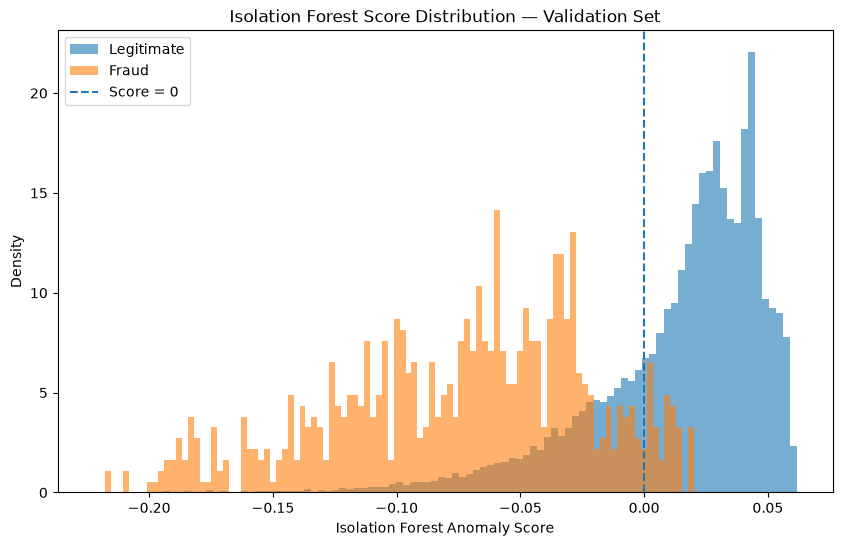

In [29]:
# ============================================================
# 13. VISUALIZE ANOMALY SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    val_scores[y_val.values == 0],
    bins=100,
    alpha=0.6,
    density=True,
    label="Legitimate"
)

plt.hist(
    val_scores[y_val.values == 1],
    bins=100,
    alpha=0.6,
    density=True,
    label="Fraud"
)

plt.axvline(
    0,
    linestyle="--",
    label="Score = 0"
)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Density")
plt.title("Isolation Forest Score Distribution — Validation Set")
plt.legend()

plt.show()

In [30]:
# ============================================================
# 14. FIND OPTIMAL ANOMALY THRESHOLD
# ============================================================

from sklearn.metrics import precision_recall_curve

In [35]:
# Convert Isolation Forest scores into fraud-risk scores
# Higher risk score = more anomalous
val_risk_scores = -val_scores

# Calculate precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_risk_scores
)

# Calculate F1 score
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Find threshold with maximum F1
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_precision = precision[best_index]
best_recall = recall[best_index]
best_f1 = f1_scores[best_index]

print("Best validation threshold:", best_threshold)
print("Validation Precision:", best_precision)
print("Validation Recall:", best_recall)
print("Validation F1-score:", best_f1)

Best validation threshold: 0.09158423541512584
Validation Precision: 0.3289315726290516
Validation Recall: 0.35400516795865633
Validation F1-score: 0.3410080895580325


In [ ]:
# ============================================================
# 15. EVALUATE ISOLATION FOREST ON TEST SET
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)


In [44]:
# Convert test scores to fraud-risk scores
test_risk_scores = -test_scores

y_test_pred_if = (test_risk_scores >= best_threshold).astype(int)

test_precision = precision_score(y_test, y_test_pred_if, zero_division=0)

test_recall = recall_score(y_test, y_test_pred_if, zero_division=0)

test_f1 = f1_score(y_test, y_test_pred_if, zero_division=0)

test_pr_auc = average_precision_score(y_test, test_risk_scores)

cm = confusion_matrix(y_test, y_test_pred_if)

print("Isolation Forest — Test Set")
print("-" * 50)

print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"PR-AUC:    {test_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_if,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Isolation Forest — Test Set
--------------------------------------------------
Precision: 0.2533
Recall:    0.3753
F1-score:  0.3024
PR-AUC:    0.2227

Confusion Matrix:
[[64880   914]
 [  516   310]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     65794
       Fraud       0.25      0.38      0.30       826

    accuracy                           0.98     66620
   macro avg       0.62      0.68      0.65     66620
weighted avg       0.98      0.98      0.98     66620



In [46]:
# ============================================================
# 16A. CALCULATE CLASS IMBALANCE WEIGHT
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Legitimate transactions:", negative_count)
print("Fraud transactions:", positive_count)
print("Fraud rate:", f"{positive_count / len(y_train) * 100:.4f}%")
print("Scale positive weight:", round(scale_pos_weight, 2))

Legitimate transactions: 6252434
Fraud transactions: 6613
Fraud rate: 0.1057%
Scale positive weight: 945.48
